# Walking EDA
Exploratory data analysis of my Apple Watch walking workouts (March 2024 to September 2026, 106 walks). All cleaning and feature engineering happens in `clean.ipynb`; this notebook only explores and visualizes.

**Highlights** (marked ⭐ below)
- The core distributions of distance, duration, speed and heart rate
- Walks per day of the week
- The two calendar heatmaps: day × hour and year × month
- Calories vs distance and duration vs distance, where near-perfect linear fits show the watch data behaves as expected

**Contents**
1. Setup
2. Load & overview
3. Distributions ⭐
4. Walking habits ⭐
5. Trends over time
6. Relationships & linear regression ⭐
7. Correlations
8. Speed by walk length
9. Key findings

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (9, 5)})

# Consistent colours and orders, reused by every chart
SEASON_ORDER = ["Spring", "Summer", "Fall", "Winter"]
SEASON_PALETTE = {"Spring": "#1baf7a", "Summer": "#eb6834", "Fall": "#4a3aa7", "Winter": "#2a78d6"}

YEAR_ORDER = [2024, 2025, 2026]
YEAR_PALETTE = dict(zip(YEAR_ORDER, sns.color_palette("crest", n_colors=3)))

WEEKEND_PALETTE = {"Weekday": "#a0a7b0", "Weekend": "#2a78d6"}
WEEKEND_LABELS = {False: "Weekday", True: "Weekend"}  # for hue=df["is_weekend"].map(WEEKEND_LABELS)

DAY_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
TIME_ORDER = ["Morning", "Midday", "Afternoon", "Evening"]
BAND_ORDER = ["Short <2km", "Medium 2-4km", "Long 4km+"]

In [3]:
def regression_stats(x, y, order=1):
    """Fit a polynomial with least squares and return its coefficients and R squared."""
    coefs = np.polyfit(x, y, order)
    predicted = np.polyval(coefs, x)
    r2 = 1 - np.sum((y - predicted) ** 2) / np.sum((y - np.mean(y)) ** 2)
    return coefs, r2


def add_regression_stats(ax, x, y, order=1, loc="upper left"):
    """Write the fitted equation and R squared in the corner of a chart."""
    coefs, r2 = regression_stats(x, y, order)
    if order == 1:
        label = f"y = {coefs[0]:.3g}x + {coefs[1]:.3g}\nR² = {r2:.2f}"
    else:
        label = f"order {order} fit\nR² = {r2:.2f}"
    x_pos, ha = (0.03, "left") if "left" in loc else (0.97, "right")
    y_pos, va = (0.95, "top") if "upper" in loc else (0.05, "bottom")
    ax.text(x_pos, y_pos, label, transform=ax.transAxes, ha=ha, va=va,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="#cccccc"))
    return coefs, r2

## 2. Load & overview
Load the cleaned data and get a feel for its size and headline totals.

In [4]:
df = pd.read_csv("../data/processed/clean_walks.csv")

# Dates are stored with local UTC offsets, so parse through UTC back to local time
for col in ["startDate", "endDate"]:
    df[col] = pd.to_datetime(df[col], utc=True).dt.tz_convert("America/Halifax")

df.head(2)

,startDate,endDate,walk_number,distance_km,cumulative_km,distance_band,duration,pace,speed,calories_active,...,metres_per_beat,year,season,month,day,day_of_week,day_name,is_weekend,hour,time_of_day
0,2024-03-09 16:03:18-04:00,2024-03-09 16:26:46-04:00,1,1.70326,1.70326,Short <2km,23.467609,13.778054,4.354751,83.9084,...,0.684406,2024,Spring,3,9,5,Sat,True,16,Afternoon
1,2024-03-16 14:36:43-03:00,2024-03-16 15:23:49-03:00,2,3.02969,4.73295,Medium 2-4km,45.893084,15.147782,3.960976,187.3350,...,0.620232,2024,Spring,3,16,5,Sat,True,14,Afternoon


In [5]:
df.shape

(106, 27)

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
walk_number,106.0,53.50,30.74,1.00,27.25,53.50,79.75,106.00
distance_km,106.0,2.74,1.83,0.63,1.53,2.08,3.57,11.59
cumulative_km,106.0,134.98,87.63,1.70,51.57,135.50,209.42,290.55
duration,106.0,39.90,27.98,10.18,20.77,31.39,49.90,151.49
pace,106.0,14.76,3.72,9.53,11.86,14.08,16.36,28.57
speed,106.0,4.29,0.93,2.10,3.67,4.26,5.06,6.30
calories_active,106.0,198.07,147.56,46.17,102.71,151.16,249.46,816.91
calories_basal,106.0,65.87,46.43,16.73,34.20,51.94,82.68,251.13
calories_total,106.0,263.93,191.00,64.27,143.31,195.46,338.64,1035.89
calories_per_km,106.0,95.70,21.03,58.23,84.43,91.25,99.90,216.44


In [7]:
# Headline numbers
print(f"Total walks:     {len(df)}")
print(f"Total distance:  {df['distance_km'].sum():.1f} km")
print(f"Total time:      {df['duration'].sum() / 60:.1f} hours")
print(f"Total calories:  {df['calories_total'].sum():,.0f} kcal")
print(f"Longest walk:    {df['distance_km'].max():.2f} km")
print(f"Fastest walk:    {df['speed'].max():.2f} km/h")
print(f"Average walk:    {df['distance_km'].mean():.2f} km in {df['duration'].mean():.0f} min")

Total walks:     106
Total distance:  290.6 km
Total time:      70.5 hours
Total calories:  27,977 kcal
Longest walk:    11.59 km
Fastest walk:    6.30 km/h
Average walk:    2.74 km in 40 min


**At a glance**
- 106 walks covering 290.6 km and 70.5 hours
- The average walk is 2.74 km in about 40 minutes
- Longest walk: 11.59 km. Fastest walk: 6.30 km/h

## 3. Distributions ⭐
What does a typical walk look like?

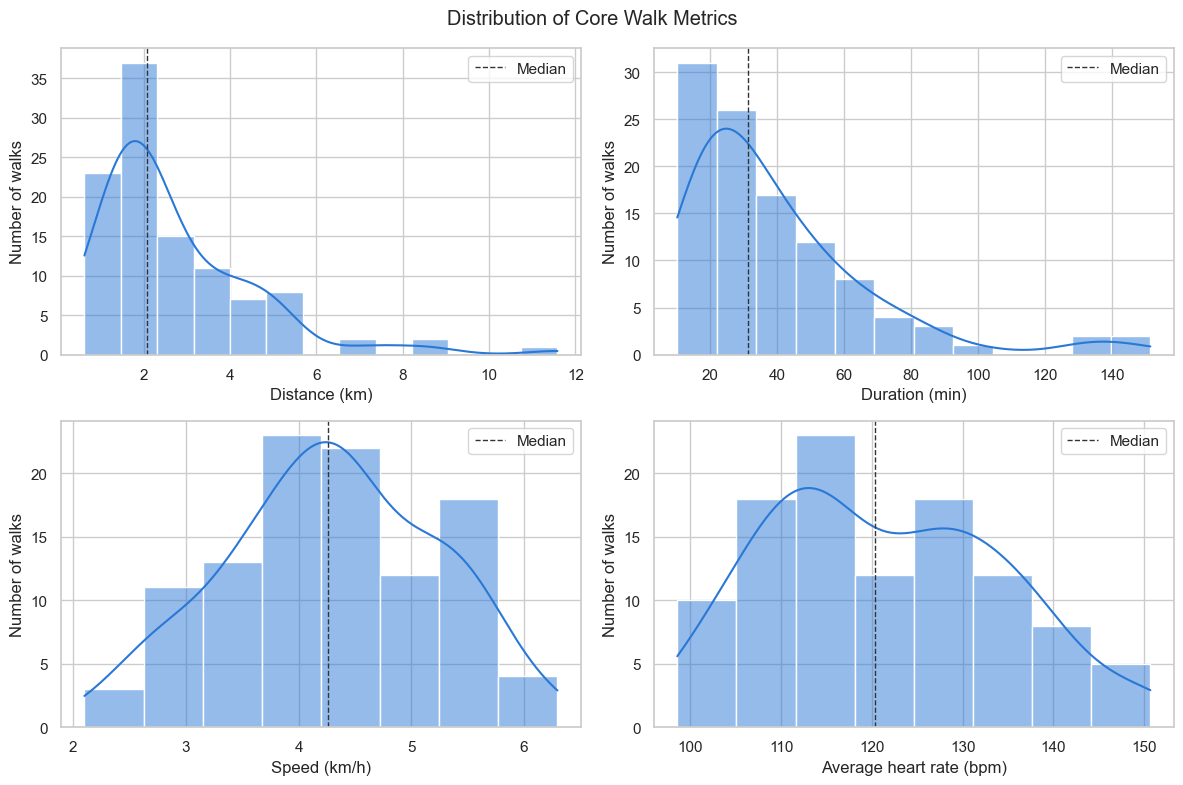

In [8]:
metrics = {
    "distance_km": "Distance (km)",
    "duration": "Duration (min)",
    "speed": "Speed (km/h)",
    "heart_rate_average": "Average heart rate (bpm)",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, label) in zip(axes.flat, metrics.items()):
    sns.histplot(data=df, x=col, kde=True, color="#2a78d6", ax=ax)
    ax.axvline(df[col].median(), color="#333333", linestyle="--", linewidth=1, label="Median")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of walks")
    ax.legend()
fig.suptitle("Distribution of Core Walk Metrics")
plt.tight_layout()

**Insights**
- Distance and duration are strongly **right skewed**: the typical walk is about 2.1 km and 31 minutes, with a few 7 to 12 km walks stretching the tail
- Speed (median 4.3 km/h) and average heart rate (median 120 bpm) are close to **symmetric**
- For distance and duration the **median** is the better summary; for speed and heart rate the mean works fine

#### Speed by season

In [10]:
# Median speed per season, to back up the chart
df.groupby("season")["speed"].agg(["count", "median"]).loc[SEASON_ORDER].round(2)

,count,median
season,,
Spring,41,4.26
Summer,39,4.10
Fall,13,4.39
Winter,13,4.47


**Insights**
- Speed barely changes with the season: medians range from 4.1 km/h (Summer) to 4.5 km/h (Winter)
- Summer is slightly the slowest, which fits heat and leisurely summer strolls
- Fall and Winter have only 13 walks each, so treat those numbers with caution

#### Distance by year

In [12]:
df.groupby("year")["distance_km"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2024,24.0,1.82,1.38,0.63,1.13,1.41,2.04,7.21
2025,20.0,2.57,1.58,0.70,1.88,2.09,2.66,8.31
2026,62.0,3.15,1.94,0.83,1.68,2.42,4.38,11.59


**Insights**
- Walks are getting **longer every year**: the median went from 1.4 km (2024) to 2.1 km (2025) to 2.4 km (2026)
- The share of walks over 4 km rose from 4% (2024) to 10% (2025) to 27% (2026)
- 2026 also has the most variety (std 1.94 km) and the longest walk (11.6 km)

## 4. Walking habits ⭐
When do I walk: which months, days and hours?

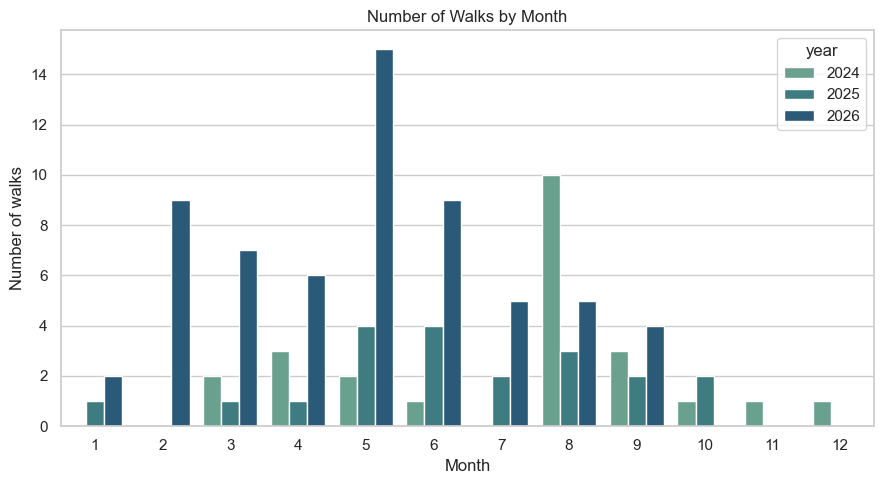

In [14]:
ax = sns.countplot(data=df, x="month", hue="year", hue_order=YEAR_ORDER, palette=YEAR_PALETTE)
ax.set_title("Number of Walks by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of walks")
plt.tight_layout()

**Insights**
- 2026 is by far the busiest year: 62 of 106 walks, peaking at 15 walks in May 2026
- Earlier years had occasional bursts, such as 10 walks in August 2024
- November through January are consistently quiet

#### Walks by day of week ⭐

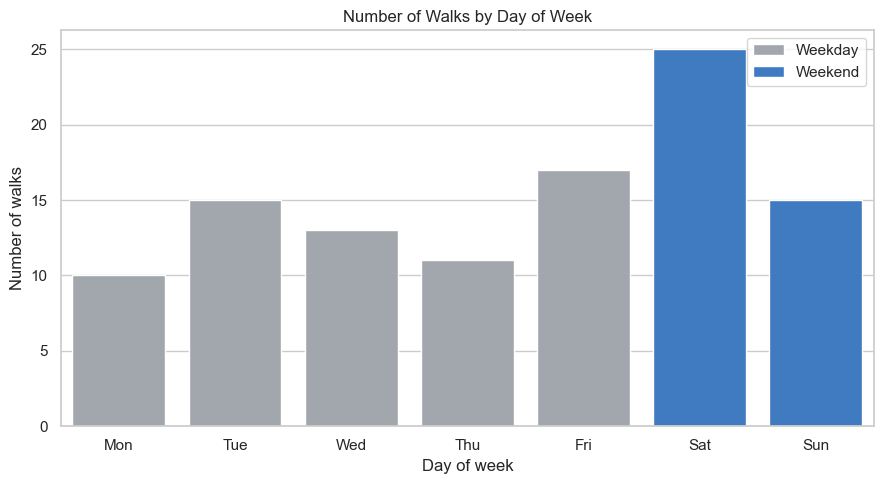

In [15]:
ax = sns.countplot(data=df, x="day_name", order=DAY_ORDER, hue=df["is_weekend"].map(WEEKEND_LABELS),
                   hue_order=["Weekday", "Weekend"], palette=WEEKEND_PALETTE)
ax.set_title("Number of Walks by Day of Week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Number of walks")
ax.get_legend().set_title("")
plt.tight_layout()

**Insights**
- **Saturday** is the most popular day with 25 walks, almost 1 in 4
- **Monday** is the least popular with 10 walks
- Weekends account for 38% of walks despite being only 2 of 7 days

#### Walk start time

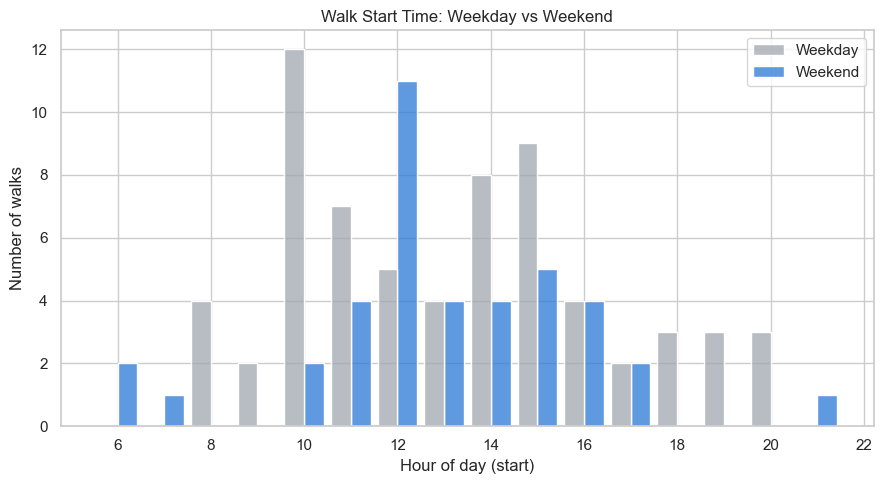

In [16]:
ax = sns.histplot(data=df, x="hour", hue=df["is_weekend"].map(WEEKEND_LABELS),
                  hue_order=["Weekday", "Weekend"], palette=WEEKEND_PALETTE,
                  binwidth=1, discrete=True, multiple="dodge", shrink=0.85)
ax.set_title("Walk Start Time: Weekday vs Weekend")
ax.set_xlabel("Hour of day (start)")
ax.set_ylabel("Number of walks")
ax.get_legend().set_title("")
plt.tight_layout()

**Insights**
- Most walks start between 10:00 and 16:00
- Weekday walks cluster around 10:00 and 14:00 to 15:00, like a morning break and an afternoon walk
- Weekend walks peak at midday (12:00)
- Very early (before 8:00) and late (after 18:00) walks are rare

#### Calendar heatmaps ⭐
Two views of the same habit: *when in the week* I walk, and *how much* I walk each month.

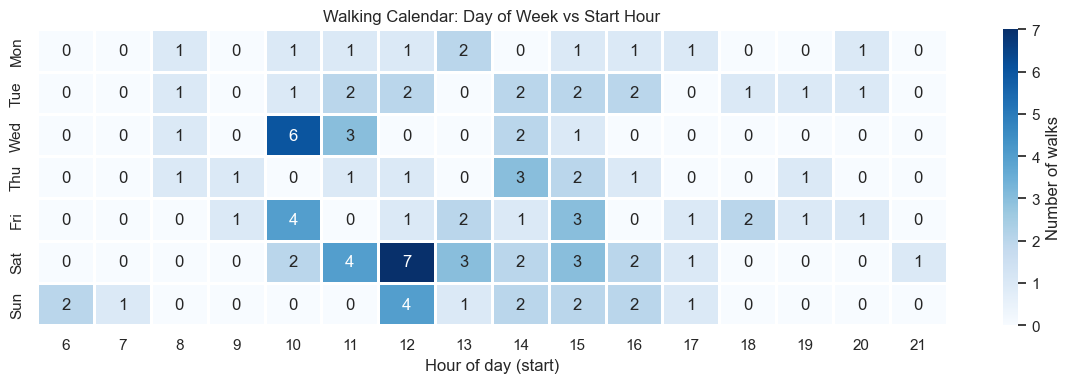

In [17]:
day_hour = (
    df.pivot_table(index="day_name", columns="hour", values="distance_km", aggfunc="size", fill_value=0)
    .reindex(DAY_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(day_hour, annot=True, fmt="d", cmap="Blues", linewidths=1, linecolor="white",
            cbar_kws={"label": "Number of walks"}, ax=ax)
ax.set_title("Walking Calendar: Day of Week vs Start Hour")
ax.set_xlabel("Hour of day (start)")
ax.set_ylabel("")
plt.tight_layout()

**Insights**
- Two clear hot spots: **Saturday at 12:00** (7 walks) and **Wednesday at 10:00** (6 walks)
- These look like established routines rather than random timing

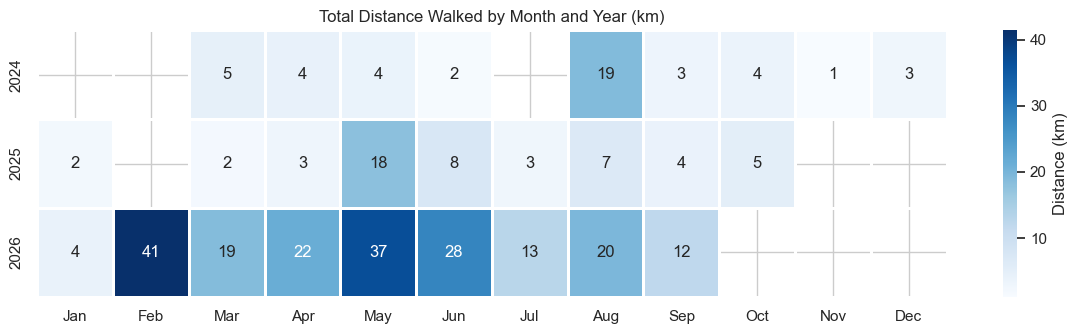

In [18]:
year_month = (
    df.pivot_table(index="year", columns="month", values="distance_km", aggfunc="sum")
    .reindex(columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(year_month, annot=True, fmt=".0f", cmap="Blues", linewidths=1, linecolor="white",
            cbar_kws={"label": "Distance (km)"}, ax=ax)
ax.set_title("Total Distance Walked by Month and Year (km)")
ax.set_xticks(np.arange(12) + 0.5, ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

**Insights**
- February 2026 (41 km) and May 2026 (37 km) are the biggest months on record
- Every month of 2026 so far beats the same month in 2024 and 2025
- The 2026 row is consistently darker than 2024 and 2025

## 5. Trends over time
Am I walking more?

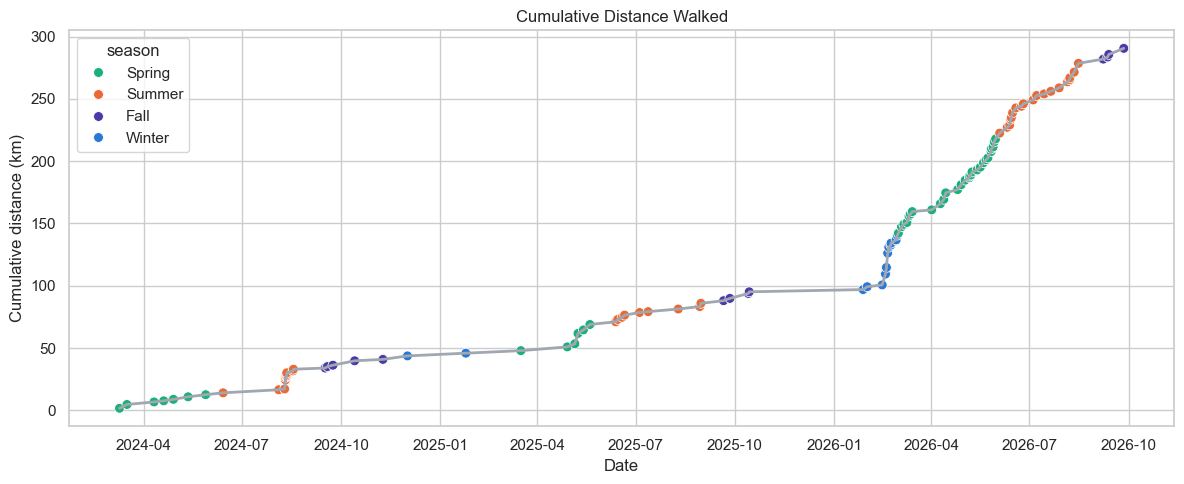

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df, x="startDate", y="cumulative_km", color="#a0a7b0", linewidth=2, ax=ax)
sns.scatterplot(data=df, x="startDate", y="cumulative_km", hue="season", hue_order=SEASON_ORDER,
                palette=SEASON_PALETTE, s=50, edgecolor="white", ax=ax)
ax.set_title("Cumulative Distance Walked")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative distance (km)")
plt.tight_layout()

**Insights**
- Cumulative distance grew slowly through 2024 and 2025: about 95 km in two years
- The curve steepens sharply in 2026, adding almost 200 km in 9 months
- **The headline story: 2026 has roughly doubled my walking**

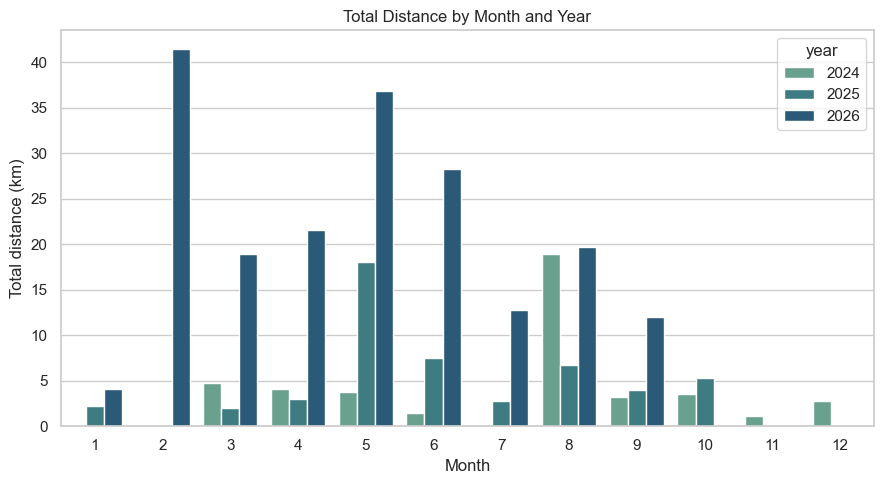

In [21]:
ax = sns.barplot(data=df, x="month", y="distance_km", hue="year", hue_order=YEAR_ORDER, palette=YEAR_PALETTE,
                 estimator="sum", errorbar=None)
ax.set_title("Total Distance by Month and Year")
ax.set_xlabel("Month")
ax.set_ylabel("Total distance (km)")
plt.tight_layout()

**Insights**
- Totals make the jump even clearer: 195 km in 2026 so far vs 44 km (2024) and 51 km (2025)
- February 2026 stands out because of several long walks, not just more walks

## 6. Relationships & linear regression ⭐
Least squares straight line fits to the main relationships. Each chart shows the fitted equation and R², the share of variation the line explains (0 to 1). The shaded band is the 95% confidence interval.

The first two charts are a **sanity check on the data**: calories and duration should both scale with distance, and they do, almost perfectly.

Text(0.5, 1.02, 'Calories Burned vs Distance')

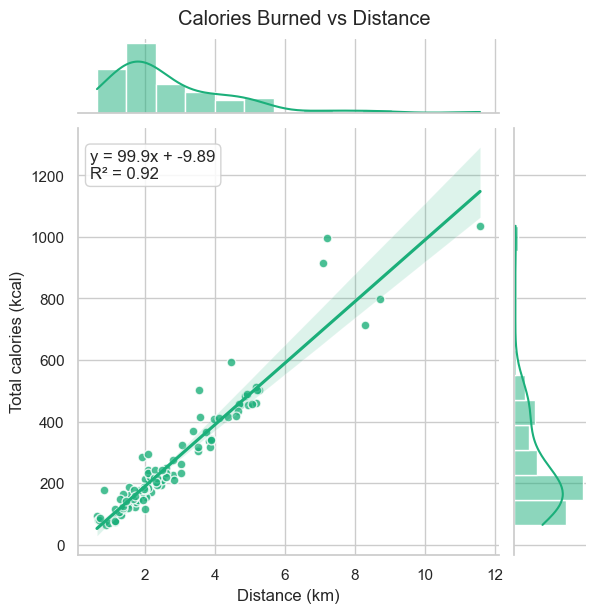

In [27]:
g = sns.jointplot(data=df, x="distance_km", y="calories_total", kind="reg", color="#1baf7a",
                  height=6, joint_kws={"scatter_kws": {"s": 40, "edgecolor": "white"}, "seed": 42})
add_regression_stats(g.ax_joint, df["distance_km"], df["calories_total"])
g.set_axis_labels("Distance (km)", "Total calories (kcal)")
g.figure.suptitle("Calories Burned vs Distance", y=1.02)

**Insights**
- The strongest relationship in the data: **R² = 0.92**
- Each km burns about **100 kcal**, a clean rule of thumb and a good dashboard KPI
- Points above the line at about 7 km are longer, slower walks where basal calories add up over time

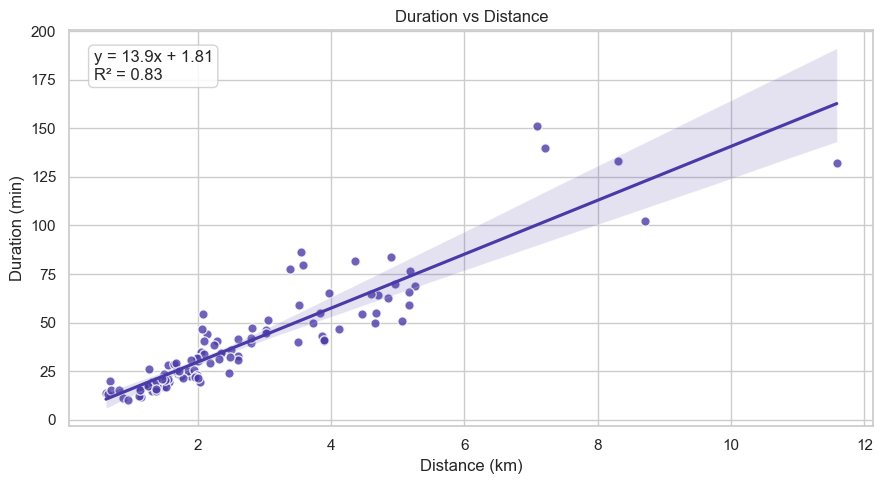

In [28]:
ax = sns.regplot(data=df, x="distance_km", y="duration", color="#4a3aa7",
                 scatter_kws={"s": 45, "edgecolor": "white"}, seed=42)
add_regression_stats(ax, df["distance_km"], df["duration"])
ax.set_title("Duration vs Distance")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Duration (min)")
plt.tight_layout()

**Insights**
- Each km takes about **13.9 minutes** (**R² = 0.83**), which is a pace of roughly 4.3 km/h
- Points above the line are slower, more leisurely walks
- Long walks spread out more, since pace varies more over longer distances

**Why these two matter:** both fits are tight and physically sensible (about 100 kcal/km and about 14 min/km). The watch data is consistent and trustworthy, so the rest of the analysis rests on solid ground.

#### Heart rate vs speed

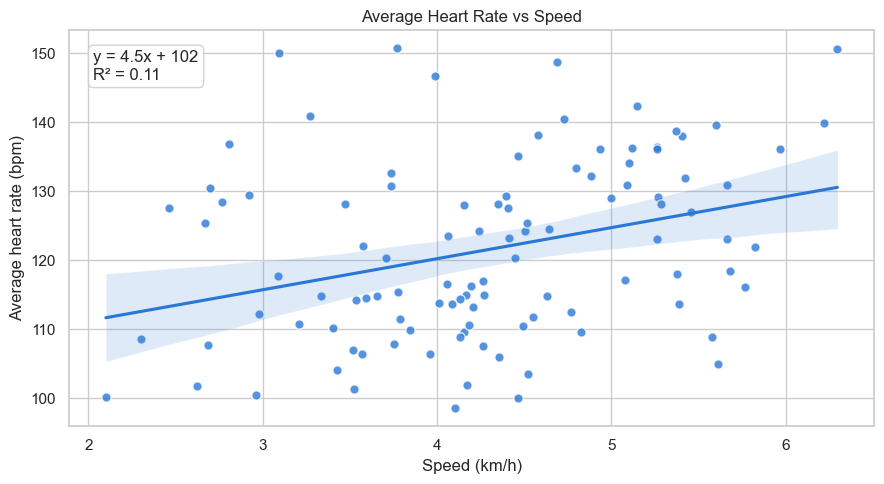

In [22]:
ax = sns.regplot(data=df, x="speed", y="heart_rate_average", color="#2a78d6",
                 scatter_kws={"s": 45, "edgecolor": "white"}, seed=42)
add_regression_stats(ax, df["speed"], df["heart_rate_average"])
ax.set_title("Average Heart Rate vs Speed")
ax.set_xlabel("Speed (km/h)")
ax.set_ylabel("Average heart rate (bpm)")
plt.tight_layout()

**Insights**
- Heart rate rises about **4.5 bpm per extra 1 km/h**, as expected
- But **R² is only 0.11**: speed explains just 11% of the variation in heart rate
- Weather, terrain, walk length and day to day condition matter more than speed alone

## 7. Correlations
Pearson correlation between every pair of numeric walk metrics.

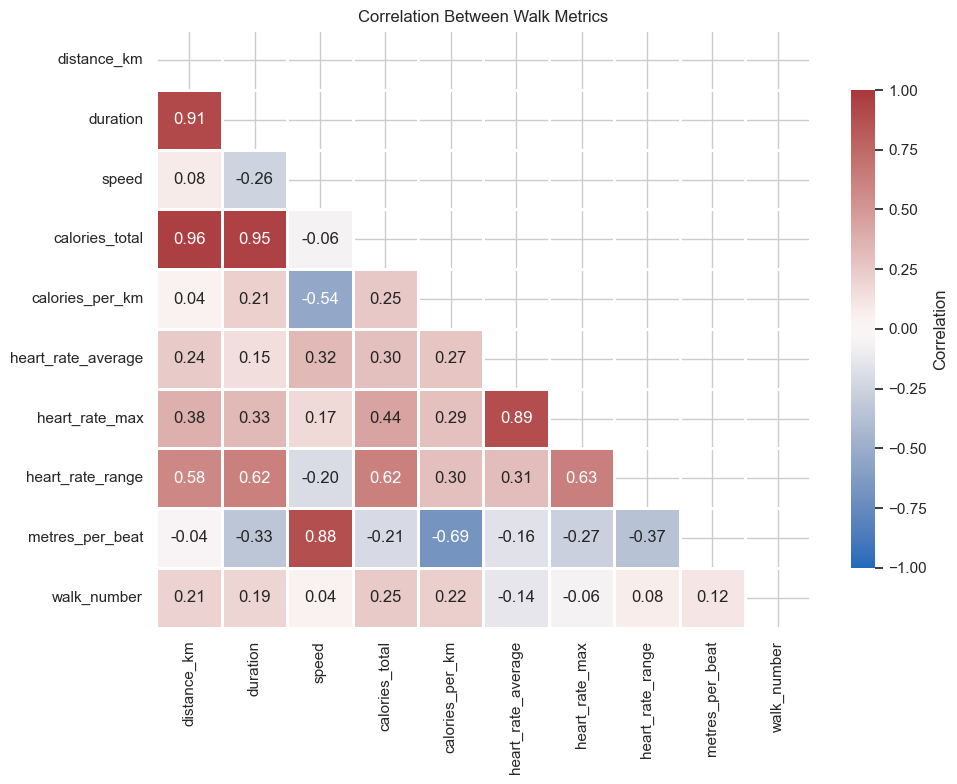

In [30]:
corr_cols = ["distance_km", "duration", "speed", "calories_total", "calories_per_km",
             "heart_rate_average", "heart_rate_max", "heart_rate_range", "metres_per_beat", "walk_number"]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            linewidths=1, linecolor="white", cbar_kws={"label": "Correlation", "shrink": 0.8}, ax=ax)
ax.set_title("Correlation Between Walk Metrics")
plt.tight_layout()

**Insights**
- Distance, duration and total calories move almost in lockstep (0.91 to 0.96)
- Speed is nearly independent of distance (0.08), so longer walks are not slower
- Metres per beat is driven mostly by speed (0.88)
- Heart rate range grows with walk length (0.58), since longer walks have more hills and variation

## 8. Speed by walk length
Do longer walks mean slower walks?

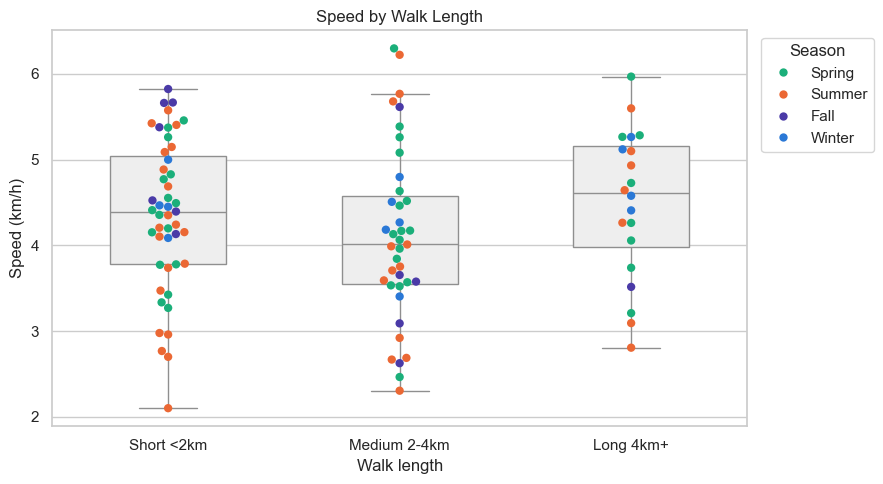

In [32]:
ax = sns.boxplot(data=df, x="distance_band", y="speed", order=BAND_ORDER, color="#eeeeee",
                 showfliers=False, width=0.5)
sns.swarmplot(data=df, x="distance_band", y="speed", order=BAND_ORDER, hue="season",
              hue_order=SEASON_ORDER, palette=SEASON_PALETTE, size=6, ax=ax)
ax.set_title("Speed by Walk Length")
ax.set_xlabel("Walk length")
ax.set_ylabel("Speed (km/h)")
ax.legend(title="Season", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()

**Insights**
- **Medium walks (2 to 4 km) are the slowest**, with a median of 4.0 km/h
- **Long walks (4 km+) are the fastest**, with a median of 4.6 km/h
- Long walks are likely purposeful fitness walks, while medium walks are more casual

## 9. Key findings
**Volume & habits**
- **Walking roughly doubled in 2026**: 62 walks and 195 km so far, vs 44 km in 2024 and 51 km in 2025
- **Walks are getting longer**: the median grew from 1.4 km (2024) to 2.4 km (2026)
- **Saturday is walking day**: 25 walks, with Saturday at noon the single most common slot
- **Clear routines**: most walks start between 10:00 and 16:00, with a Wednesday 10:00 habit too

**Data quality & relationships**
- **About 100 kcal per km**: calories scale almost perfectly with distance (R² = 0.92)
- **About 14 minutes per km**: duration scales tightly with distance (R² = 0.83)
- Together these confirm the watch data **accurately reflects what we'd expect**
- **Speed is a weak predictor of heart rate**: +4.5 bpm per km/h, but R² = 0.11
- **Longer walks are not slower**: long walks are actually the fastest (4.6 km/h median)

### Dashboard candidates
- KPI tiles: total walks, total km, total hours, total kcal, average kcal per km
- Cumulative distance over time (the growth story)
- Walks by day of week
- Year × month distance heatmap
- Day of week × hour heatmap (walking routine)
- Distance vs calories and distance vs duration regressions
- Heart rate vs speed regression, filterable by season and year